___

# [Estimator](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.primitives.Estimator.html) V1 - Aer

`class Estimator(*, backend_options: dict | None = None, transpile_options: dict | None = None, run_options: dict | None = None, approximation: bool = False, skip_transpilation: bool = False, abelian_grouping: bool = True)`

O EtimatorV1 do pacote Aer é a implementação do Estimator que pode utilizar a maioria das configurações do AerSimulator (threading, GPUs, optimização)

Para rodar o Estimator utilizaremos o mesmo .run() que utilizamos no AerSimulator: 

`run(circuits: Sequence[QuantumCircuit] | QuantumCircuit, observables: Sequence[BaseOperator | str] | BaseOperator | str, parameter_values: Sequence[Sequence[float]] | Sequence[float] | float | None = None, **run_options)`

___

### backend_options

- method, device
- precision, zero_threshold, enable_truncation
- executor, max_parallel_threads, max_memory_mb, max_job_size, max_shot_size 
- noise_model, basis_gates 

___

### transpile_options [[source](https://quantum.cloud.ibm.com/docs/en/api/qiskit/0.27/qiskit.compiler.transpile)]

- circuits, backend, backend_properties 
- basis_gates, coupling_map, initial_layout 


___

### run_options

- shots (None or int) – The number of shots. If None and approximation is True, it calculates the exact expectation values. Otherwise, it calculates expectation values with sampling.

- seed (int) – Set a fixed seed for the sampling.

___ 

### Shots & Approximation

- Approximation – If True, it calculates expectation values with normal distribution approximation. Note that this appproximation ignores readout errors.

‎ 

1. `Type(shots) = int` e `approximation = False`  : Sampling Estimator

Retorna um valor esperado com ruído de amostragem (sampling-noise), este é o modo de simulação padrão e mais comum. Ele imita um experimento real, executando o circuito um número fixo de vezes (shots) e calculando o valor esperado a partir das contagens de medição.

2. `Type(shots) = int` e `approximation = True` : Normal Estimator

Retorna um valor esperado com ruído de amostragem, mas o cálculo é feito usando uma aproximação de distribuição normal.

3. `shots = None` e `approximation = True` : Statevector Estimator

Retorna um valor esperado exato, Este é o modo de cálculo teórico ideal. O simulador calcula o vetor de estado final do circuito e, a partir dele, determina matematicamente o valor esperado, sem nenhuma amostragem.





In [20]:
import time
import pprint
from tqdm.notebook import tqdm
import warnings
import numpy as np

from qiskit import QuantumCircuit, schedule
from qiskit.primitives import BackendEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile
from qiskit_aer import *
from qiskit_aer.primitives import Estimator, EstimatorV2

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

In [3]:
def clifford_qc(num_qubits: int, depth: int):

    qc = QuantumCircuit(num_qubits)

    qc.h(range(num_qubits))

    for level in range(depth):

        for i in range(num_qubits):
        
            if i % 2 == 0:
                qc.s(i)
        
            else:
                qc.sdg(i)
        
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.cx(num_qubits - 1, 0)
    
    #qc.measure_all()

    return qc

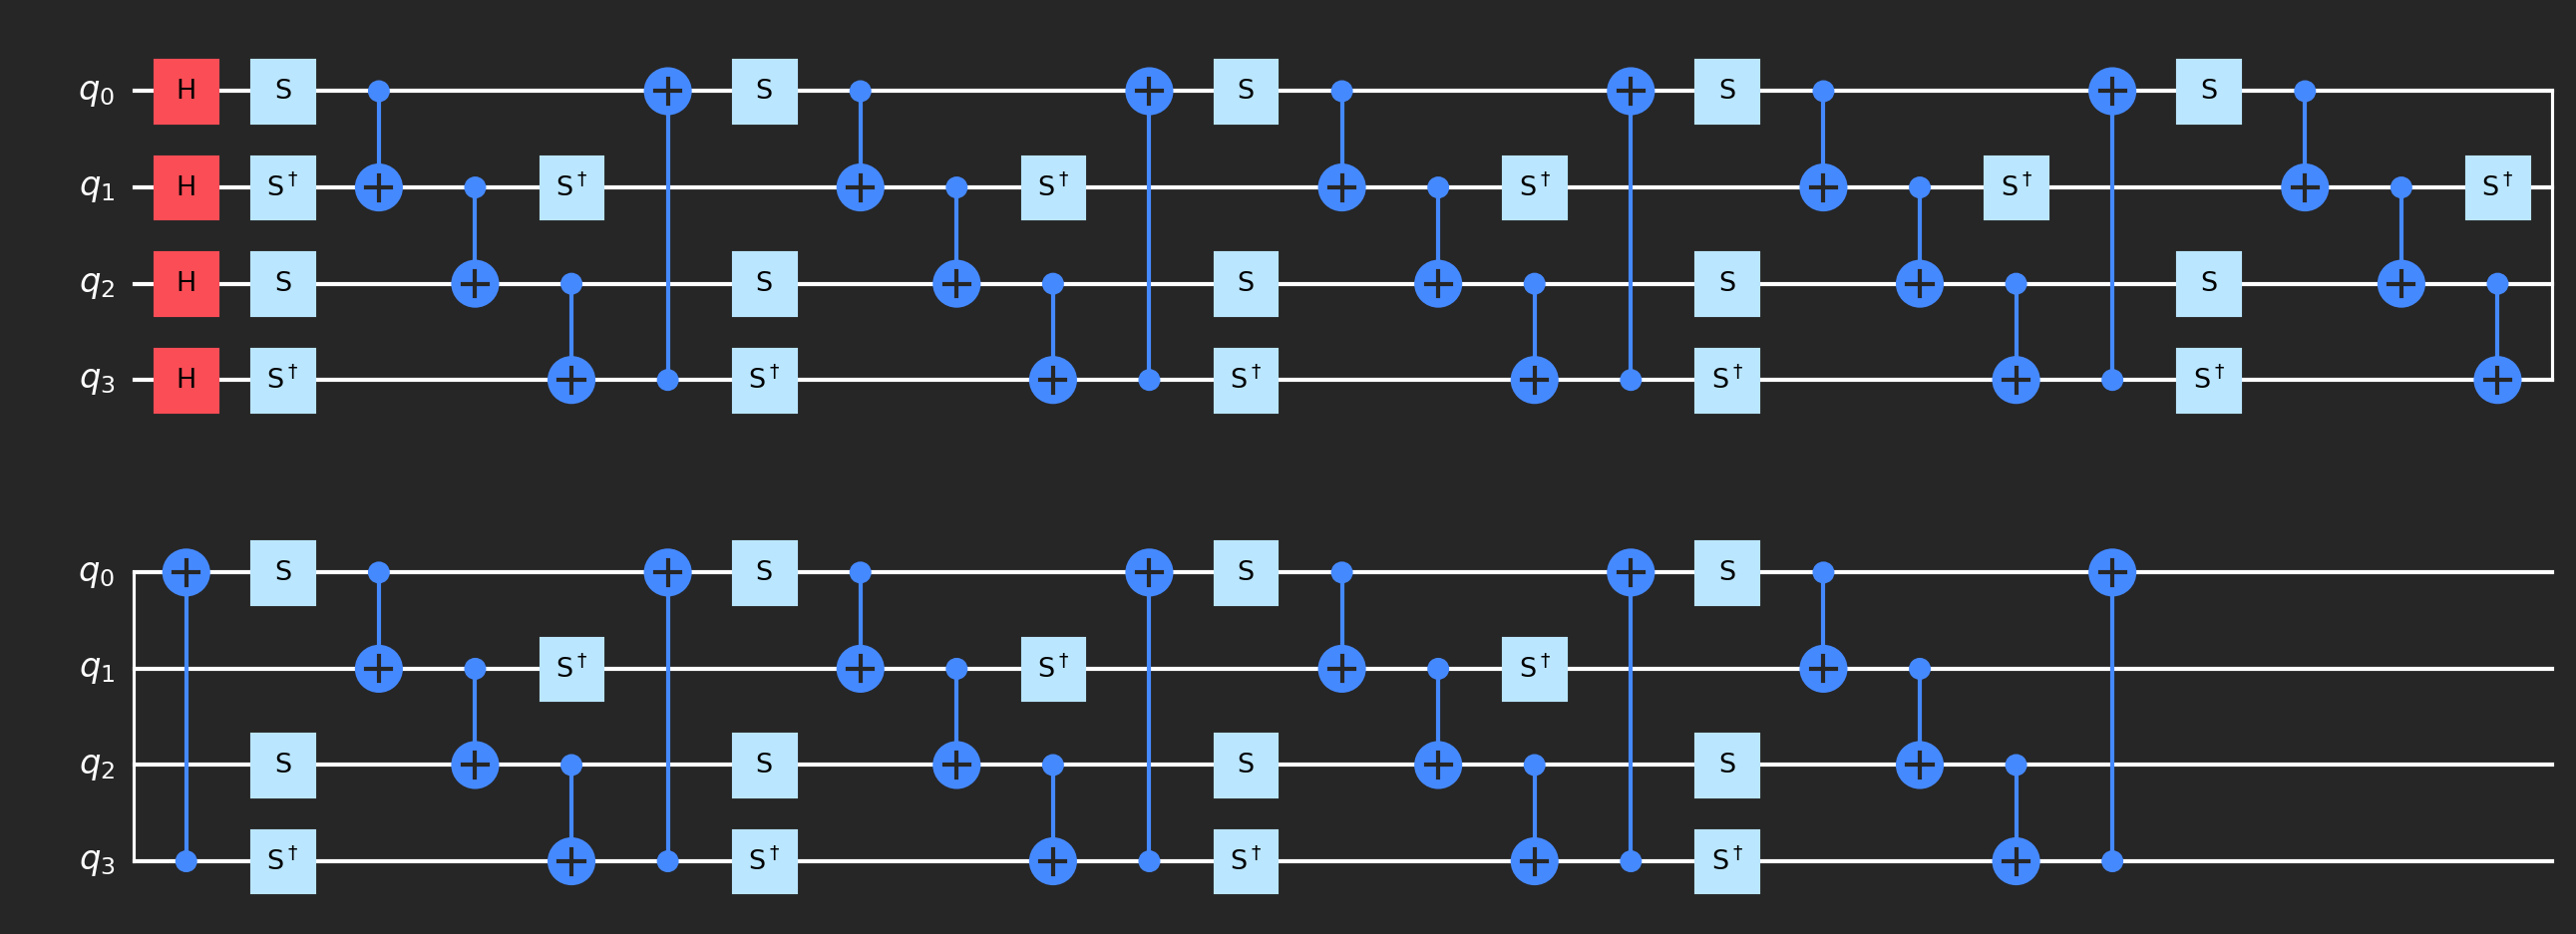

In [3]:
qc = clifford_qc(4, 9)

qc.draw()

In [4]:
observable = SparsePauliOp.from_list([("ZIII", 0.6), ("IXYI", 0.2), ("IZZI", -0.5)])

print(observable)


SparsePauliOp(['ZIII', 'IXYI', 'IZZI'],
              coeffs=[ 0.6+0.j,  0.2+0.j, -0.5+0.j])


In [5]:
estimator_sample = Estimator(approximation = True)
job_estimator = estimator_sample.run(qc, observable, shots = 2048)

print(job_estimator)

In [6]:
result_estimator = job_estimator.result()

print(result_estimator)
print(result_estimator.values)
print(result_estimator.metadata)
print(f"\nValor Esperado : {result_estimator.values[0]}\nVariancia : {result_estimator.metadata[0]['variance']}\nTempo de Simulação : {result_estimator.metadata[0]['simulator_metadata']['time_taken']}")

EstimatorResult(values=array([-0.00837969]), metadata=[{'variance': 0.65, 'shots': 2048, 'simulator_metadata': {'time_taken': 0.0055094, 'num_bind_params': 1, 'parallel_state_update': 16, 'required_memory_mb': 1, 'input_qubit_map': [[3, 3], [2, 2], [1, 1], [0, 0]], 'method': 'statevector', 'device': 'CPU', 'num_qubits': 4, 'active_input_qubits': [0, 1, 2, 3], 'num_clbits': 0, 'remapped_qubits': False, 'parallel_shots': 1, 'runtime_parameter_bind': False, 'max_memory_mb': 15882, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'result_subtypes': {'2': 'average', '1': 'average', '0': 'average'}, 'result_types': {'2': 'save_expval', '1': 'save_expval', '0': 'save_expval'}, 'fusion': {'applied': False, 'max_fused_qubits': 5, 'threshold': 14, 'enabled': True}}}])
[-0.00837969]
[{'variance': 0.65, 'shots': 2048, 'simulator_metadata': {'time_taken': 0.0055094, 'num_bind_params': 1, 'parallel_state_update': 16, 'required_memory_mb': 1, 'input_qubit_map': [[3, 3]

In [7]:
result_estimator_sample = Estimator(approximation = False).run(qc, observable, shots = 2048).result().values[0]
result_estimator_normal = Estimator(approximation = True).run(qc, observable, shots = 2048).result().values[0]
result_estimator_exact = Estimator(approximation = True).run(qc, observable, shots = None).result().values[0]

print(result_estimator_sample, result_estimator_normal, result_estimator_exact)


-0.0023437499999999986 0.00710863172886991 -1.024520887422675e-16


In [8]:
seed = 135413509

result_estimator_sample = Estimator(approximation = False).run(qc, observable, shots = 2048, seed = seed).result().values[0]
result_estimator_normal = Estimator(approximation = True).run(qc, observable, shots = 2048, seed = seed).result().values[0]
result_estimator_exact = Estimator(approximation = True).run(qc, observable, shots = None, seed = seed).result().values[0]

print(result_estimator_sample, result_estimator_normal, result_estimator_exact)


-0.005859375 0.007183243179697975 -1.024520887422675e-16


In [9]:
def expectation_value(num_qubits, depth, shots):
    
    results = {}
    
    qc = clifford_qc(num_qubits, depth)
    
    pauli_list = []
    
    for i in range(num_qubits):
        
        temp_pauli_list = ['I'] * num_qubits
        temp_pauli_list[num_qubits - 1 - i] = 'Z'
        final_pauli_list = "".join(temp_pauli_list)
        pauli_list.append((final_pauli_list, 1.0))

    observable = SparsePauliOp.from_list(pauli_list)
    
    start_time = time.time()
    estimator_sampling = Estimator(approximation = False)
    result = estimator_sampling.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Sampling Estimator : Shots = int & Approx = False"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_normal = Estimator(approximation = True)
    result = estimator_normal.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Normal Estimator : Shots = int & Approx = True"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_exact = Estimator(approximation = True)
    result = estimator_exact.run(qc, observable, shots = None).result()
    end_time = time.time()
    results["Exact Estimator : Shots = None & Approx = True"] = [result.values[0], end_time - start_time]
    
    return results


In [10]:
num_qubits, depth = 12, 15
shots = 4096

expectation_value(num_qubits = num_qubits, depth = depth, shots = shots)

/tmp/ipykernel_1076/2611584287.py:4: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  expectation_value(num_qubits = num_qubits, depth = depth, shots = shots)


{'Sampling Estimator : Shots = int & Approx = False': [0.01806640625,
  0.07572078704833984],
 'Normal Estimator : Shots = int & Approx = True': [0.03499820495374818,
  0.04305863380432129],
 'Exact Estimator : Shots = None & Approx = True': [-1.5829351718288365e-17,
  0.053830862045288086]}

In [11]:
qubit_range, depth = range(2, 16), 15
shots = 1024

method_names = [
    "Sampling Estimator",
    "Normal Estimator",
    "Exact Estimator"
]

times = {name: [] for name in method_names}
values = {name: [] for name in method_names}

for n_qubits in qubit_range:

    result = expectation_value(num_qubits=n_qubits, depth=depth, shots=shots)
    
    times["Sampling Estimator"].append(result["Sampling Estimator : Shots = int & Approx = False"][1])
    values["Sampling Estimator"].append(result["Sampling Estimator : Shots = int & Approx = False"][0])
    
    times["Normal Estimator"].append(result["Normal Estimator : Shots = int & Approx = True"][1])
    values["Normal Estimator"].append(result["Normal Estimator : Shots = int & Approx = True"][0])

    times["Exact Estimator"].append(result["Exact Estimator : Shots = None & Approx = True"][1])
    values["Exact Estimator"].append(result["Exact Estimator : Shots = None & Approx = True"][0])

/tmp/ipykernel_1076/2643031223.py:15: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  result = expectation_value(num_qubits=n_qubits, depth=depth, shots=shots)


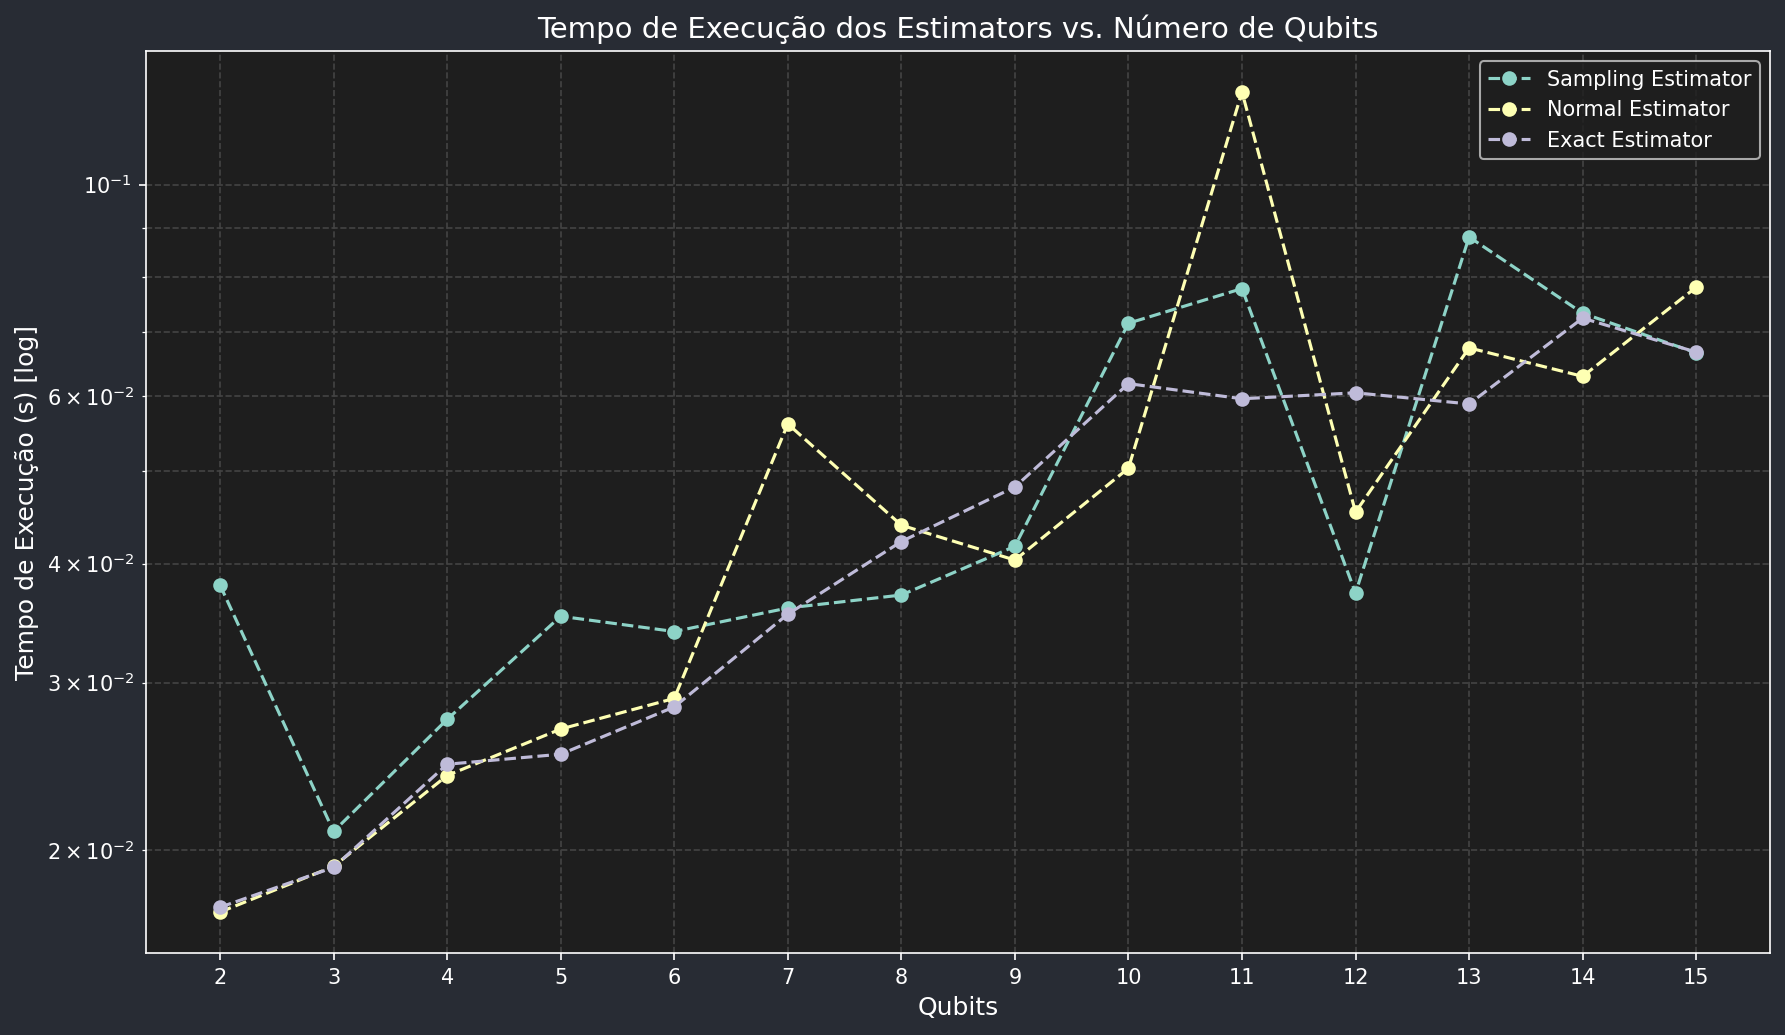

In [12]:
plt.figure(figsize=(12, 7))
for name in method_names:
    plt.plot(qubit_range, times[name], 'o--', label=name)

plt.xlabel("Qubits", fontsize=12)
plt.ylabel("Tempo de Execução (s) [log]", fontsize=12)
plt.title("Tempo de Execução dos Estimators vs. Número de Qubits", fontsize=14)
plt.yscale('log')
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

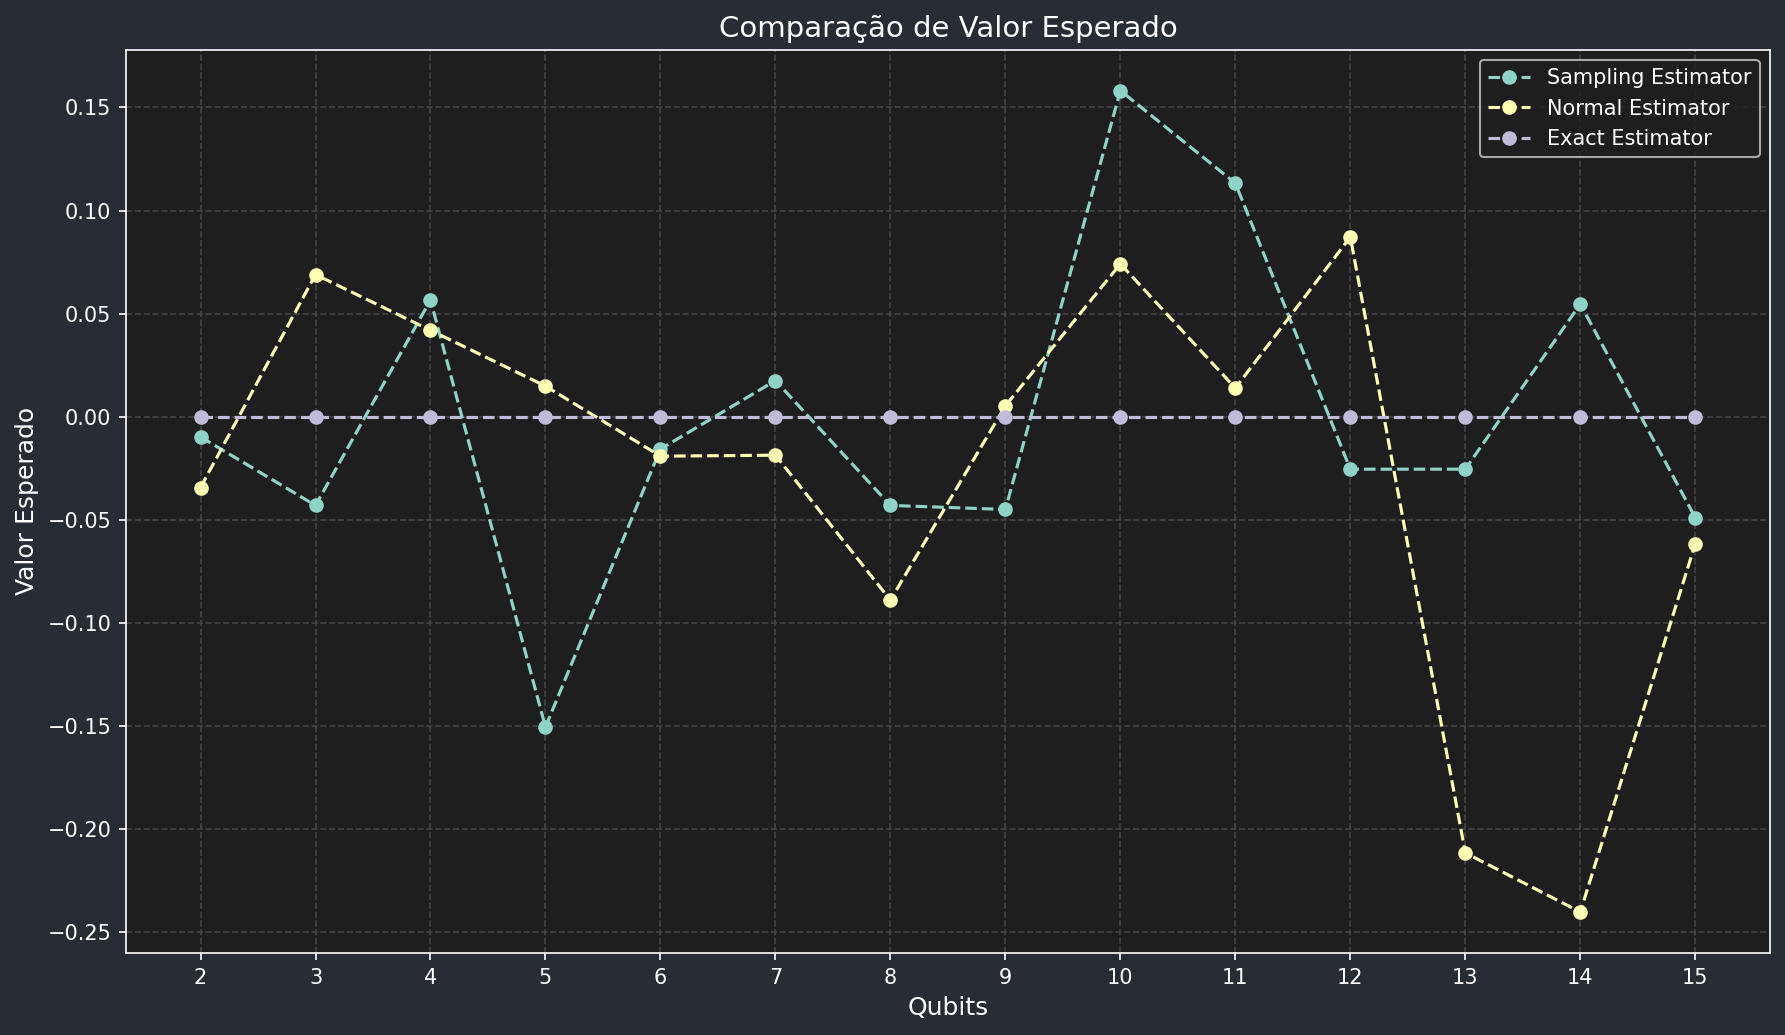

In [13]:
plt.figure(figsize=(12, 7))
for name in method_names:
    plt.plot(qubit_range, values[name], 'o--', label=name)

plt.xlabel("Qubits", fontsize=12)
plt.ylabel("Valor Esperado", fontsize=12)
plt.title("Comparação de Valor Esperado", fontsize=14)
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

___

### DeprecationWarning: Option approximation=False is deprecated

Aqui podemos ver que não é mais possível utilzar o método de  Sampling Estimator, com as propriedade de `Type(shots) = int` e `approximation = False`, o que torna o principal método de calcular valores esperados completamente obsoleto. ([StackExchange](https://quantumcomputing.stackexchange.com/questions/41562/deprecation-warnings-for-estimator-in-new-versions-of-qiskit-packages-qiskit))

Portanto, ainda podemos utilizar o **estimator com distribuição normal** e o **estimator exato**, fazendo o papel de um statevector simulator. 


___

### Alternativa para o Sampling Estimator - BackendEstimator

Ao rodar o Sampling Estimator obtemos a seguinte mensagem de erro: 

`DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.`

Portanto, devemos utilizar o BackendEstimator em conjunto com o AerSimulator para obter esse resultado.

In [14]:
aer_backend = AerSimulator()
estimator_backendestimator = BackendEstimator(backend=aer_backend)
result__backendestimator = estimator_backendestimator.run(qc, observable, shots=shots).result()

print(result__backendestimator.values[0])

0.0064453125


In [15]:
seed = 135413509

result_estimator_sample = Estimator(approximation = False).run(qc, observable, shots = 2048, seed = seed).result().values[0]
result_estimator_normal = Estimator(approximation = True).run(qc, observable, shots = 2048, seed = seed).result().values[0]
result_estimator_exact = Estimator(approximation = True).run(qc, observable, shots = None, seed = seed).result().values[0]
result__backendestimator = BackendEstimator(backend = AerSimulator()).run(qc, observable, shots=shots, seed = seed).result().values[0]

print(result_estimator_sample, result_estimator_normal, result_estimator_exact, result__backendestimator, sep = "\n")

-0.005859375
0.007183243179697975
-1.024520887422675e-16
0.0083984375



Método: Sampling Estimator
  Erro Absoluto Médio: 0.057227
  Desvio Padrão dos Erros: 0.042429

Método: Normal Estimator
  Erro Absoluto Médio: 0.050754
  Desvio Padrão dos Erros: 0.037100

Método: BackendEstimator
  Erro Absoluto Médio: 0.055244
  Desvio Padrão dos Erros: 0.043108


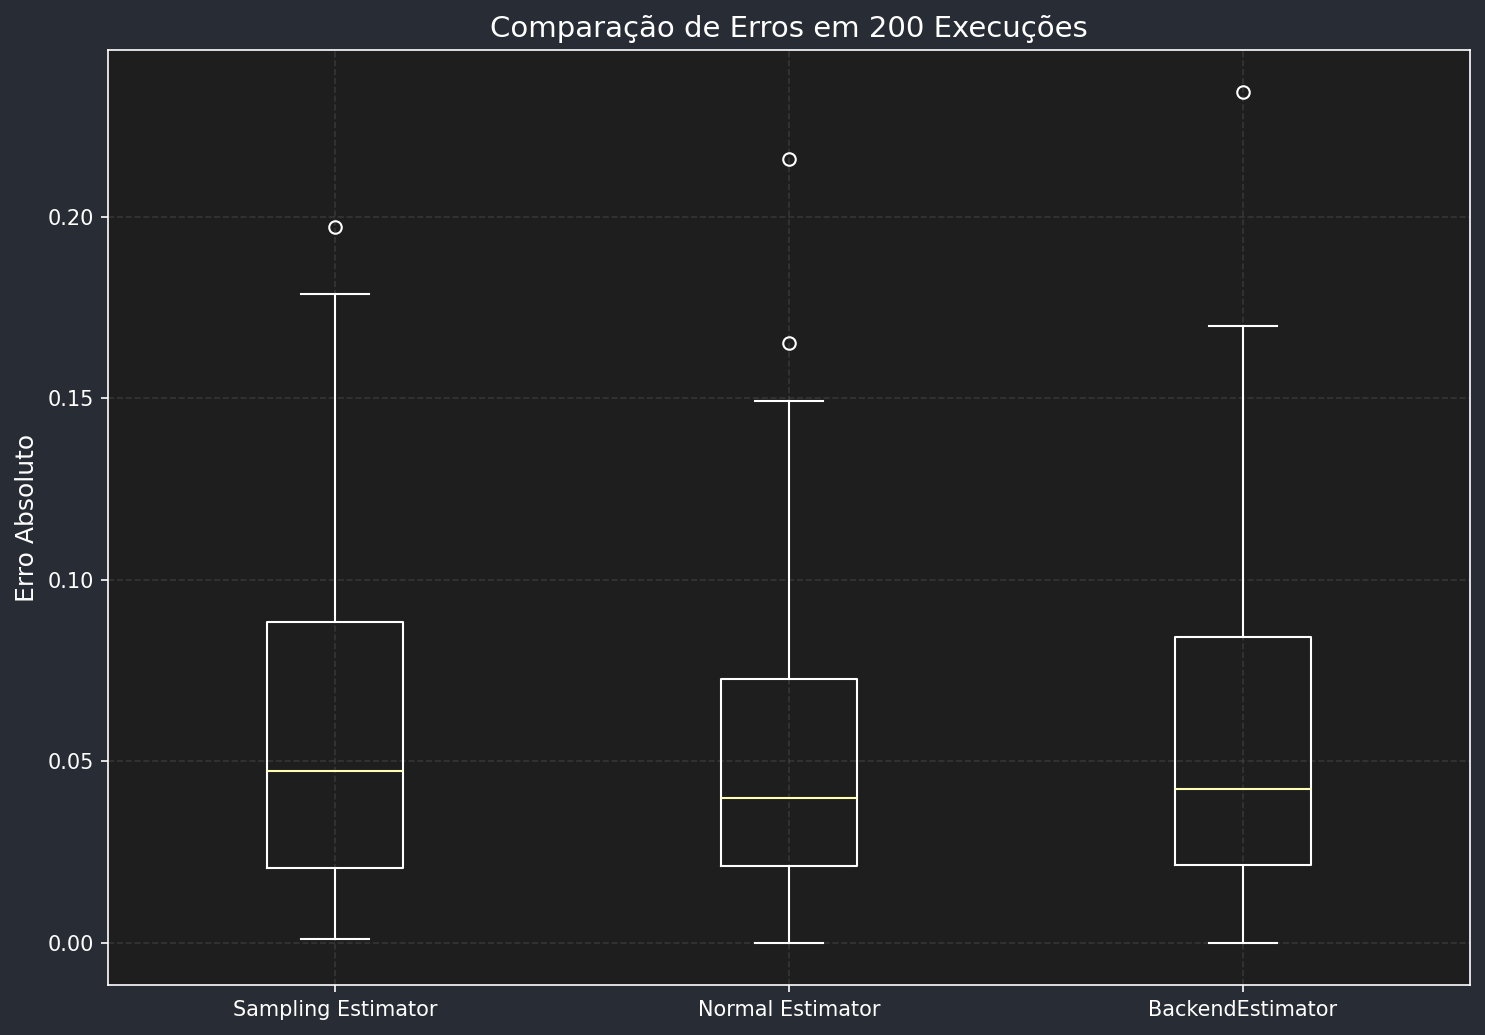

In [16]:
num_qubits = 10
depth = 12
shots = 2048
num_runs = 200

errors_sampling = []
errors_normal = []
errors_backendestimator = []

for a in range(num_runs):
    
    warnings.filterwarnings('ignore', category=DeprecationWarning)
    
    qc = clifford_qc(num_qubits, depth)
    observable = SparsePauliOp.from_list([("".join(['I']*(num_qubits-1-i) + ['Z'] + ['I']*i), 1.0) for i in range(num_qubits)])

    estimator_exact = Estimator(approximation=True)
    exact_value = estimator_exact.run(qc, observable, shots=None).result().values[0]

    estimator_sample = Estimator(approximation=False)
    sampled_value = estimator_sample.run(qc, observable, shots=shots).result().values[0]
    errors_sampling.append(abs(sampled_value - exact_value))

    estimator_normal = Estimator(approximation=True)
    normal_value = estimator_normal.run(qc, observable, shots=shots).result().values[0]
    errors_normal.append(abs(normal_value - exact_value))

    aer_backend = AerSimulator()
    backend_estimator = BackendEstimator(backend=aer_backend)
    backend_value = backend_estimator.run(qc, observable, shots=shots).result().values[0]
    errors_backendestimator.append(abs(backend_value - exact_value))

stats = {
    "Sampling Estimator": {"Média": np.mean(errors_sampling), "Desvio Padrão": np.std(errors_sampling)},
    "Normal Estimator": {"Média": np.mean(errors_normal), "Desvio Padrão": np.std(errors_normal)},
    "BackendEstimator": {"Média": np.mean(errors_backendestimator), "Desvio Padrão": np.std(errors_backendestimator)}
}

for name, data in stats.items():
    print(f"\nMétodo: {name}")
    print(f"  Erro Absoluto Médio: {data['Média']:.6f}")
    print(f"  Desvio Padrão dos Erros: {data['Desvio Padrão']:.6f}")

plt.figure(figsize=(10, 7))
plt.boxplot([errors_sampling, errors_normal, errors_backendestimator], labels=stats.keys())
plt.ylabel("Erro Absoluto", fontsize=12)
plt.title(f"Comparação de Erros em {num_runs} Execuções", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Aqui é possível ver que os erros absolutos médios são bem similares, o que mostra que os métodos são compatíveis (esperado), e mais do que isso, o sampling estmator (deprecated) obtem praticamente o mesmo resultado que o BackendEstimator, levando em consideração a mediana (linha amarela), whiskers (barras fora da caixa) e os próprios intervalos de quartil (limite inferior e superior da caixa). 

___

### Análise de Convergência dos Métodos

Para finalizar a análise de EstimatorV1 do Aer, realizaremos uma análise com os 4 possíveis Estimators do Aer : 

1. Sampling Estimator
2. Normal Estimator
3. Exact Estimator
4. BackendEstimator

E determinaremos o gráfico do valor esperado para um conjunto de qc com qubits varaindo de 2 até 15, porém, para verificar a convergência do mesmo, repetiremos cada experimento um total de 100 vezes, a fim de empregar a Lei dos Grandes Números (estamos repetindo um experimento aleatório um grande número de vezes) para verificar a convergência desses métodos. 

In [19]:
def expectation_value_total(num_qubits, depth, shots):
    
    results = {}
    
    qc = clifford_qc(num_qubits, depth)
    
    observable = SparsePauliOp.from_list([("".join(['I']*(n_qubits-1-i) + ['Z'] + ['I']*i), 1.0) for i in range(n_qubits)])
    
    start_time = time.time()
    estimator_sampling = Estimator(approximation = False)
    result = estimator_sampling.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Sampling Estimator"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_normal = Estimator(approximation = True)
    result = estimator_normal.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Normal Estimator"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_exact = Estimator(approximation = True)
    result = estimator_exact.run(qc, observable, shots = None).result()
    end_time = time.time()
    results["Exact Estimator"] = [result.values[0], end_time - start_time] 

    start_time = time.time()
    estimator_backendestimator = BackendEstimator(backend = AerSimulator())
    result = estimator_backendestimator.run(qc, observable, shots=shots).result()
    end_time = time.time()
    results["BackendEstimator"] = [result.values[0], end_time - start_time]
    
    return results

qubit_range, depth = range(2, 16), 15
shots = 1024
iterations = 100

method_names = [
    "Sampling Estimator",
    "Normal Estimator",
    "Exact Estimator",
    "BackendEstimator"
]

times = {name: [] for name in method_names}
values = {name: [] for name in method_names}

warnings.filterwarnings('ignore', category=DeprecationWarning)

for n_qubits in qubit_range:

    temp_times = {name: [] for name in method_names}
    temp_values = {name: [] for name in method_names}

    for a in range(iterations):
        
        result = expectation_value_total(num_qubits=n_qubits, depth=depth, shots=shots)
        
        temp_times["Sampling Estimator"].append(result["Sampling Estimator"][1])
        temp_values["Sampling Estimator"].append(result["Sampling Estimator"][0])
    
        temp_times["Normal Estimator"].append(result["Normal Estimator"][1])
        temp_values["Normal Estimator"].append(result["Normal Estimator"][0])

        temp_times["Exact Estimator"].append(result["Exact Estimator"][1])
        temp_values["Exact Estimator"].append(result["Exact Estimator"][0])

        temp_times["BackendEstimator"].append(result["BackendEstimator"][1])
        temp_values["BackendEstimator"].append(result["BackendEstimator"][0])

    for name in method_names:
        times[name].append(np.mean(temp_times[name]))
        values[name].append(np.mean(temp_values[name]))


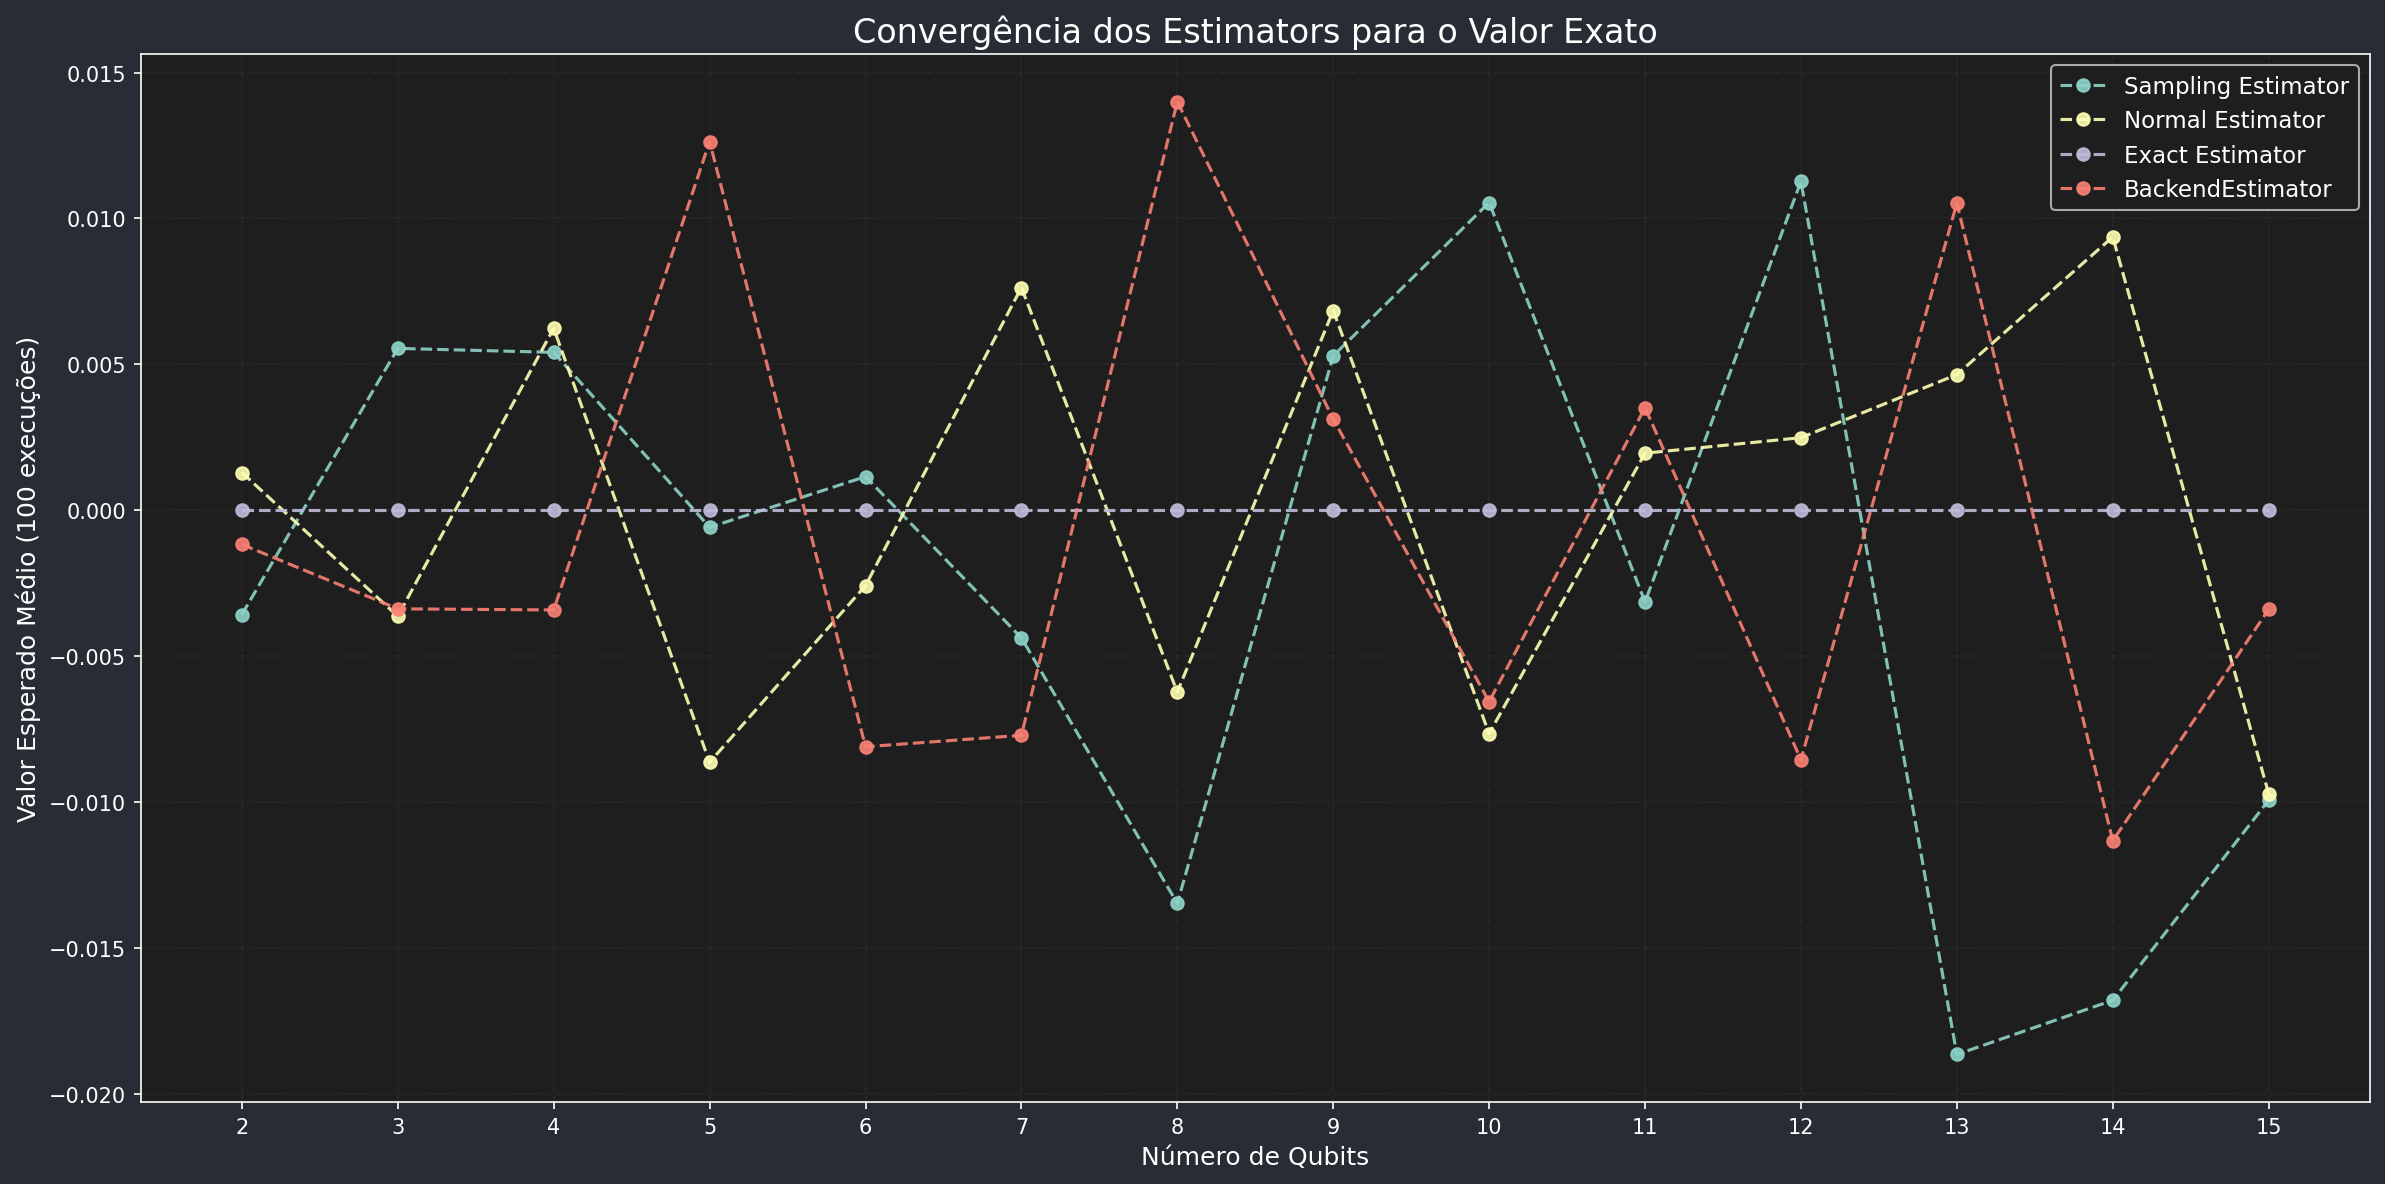

In [33]:
plt.figure(figsize=(16, 8))
for i, name in enumerate(method_names):
    plt.plot(qubit_range, values[name], "o--", label=name, alpha=0.9)

plt.xlabel("Número de Qubits", fontsize=12)
plt.ylabel("Valor Esperado Médio (100 execuções)", fontsize=12)
plt.title("Convergência dos Estimators para o Valor Exato", fontsize=16)
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--", alpha=0.25)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

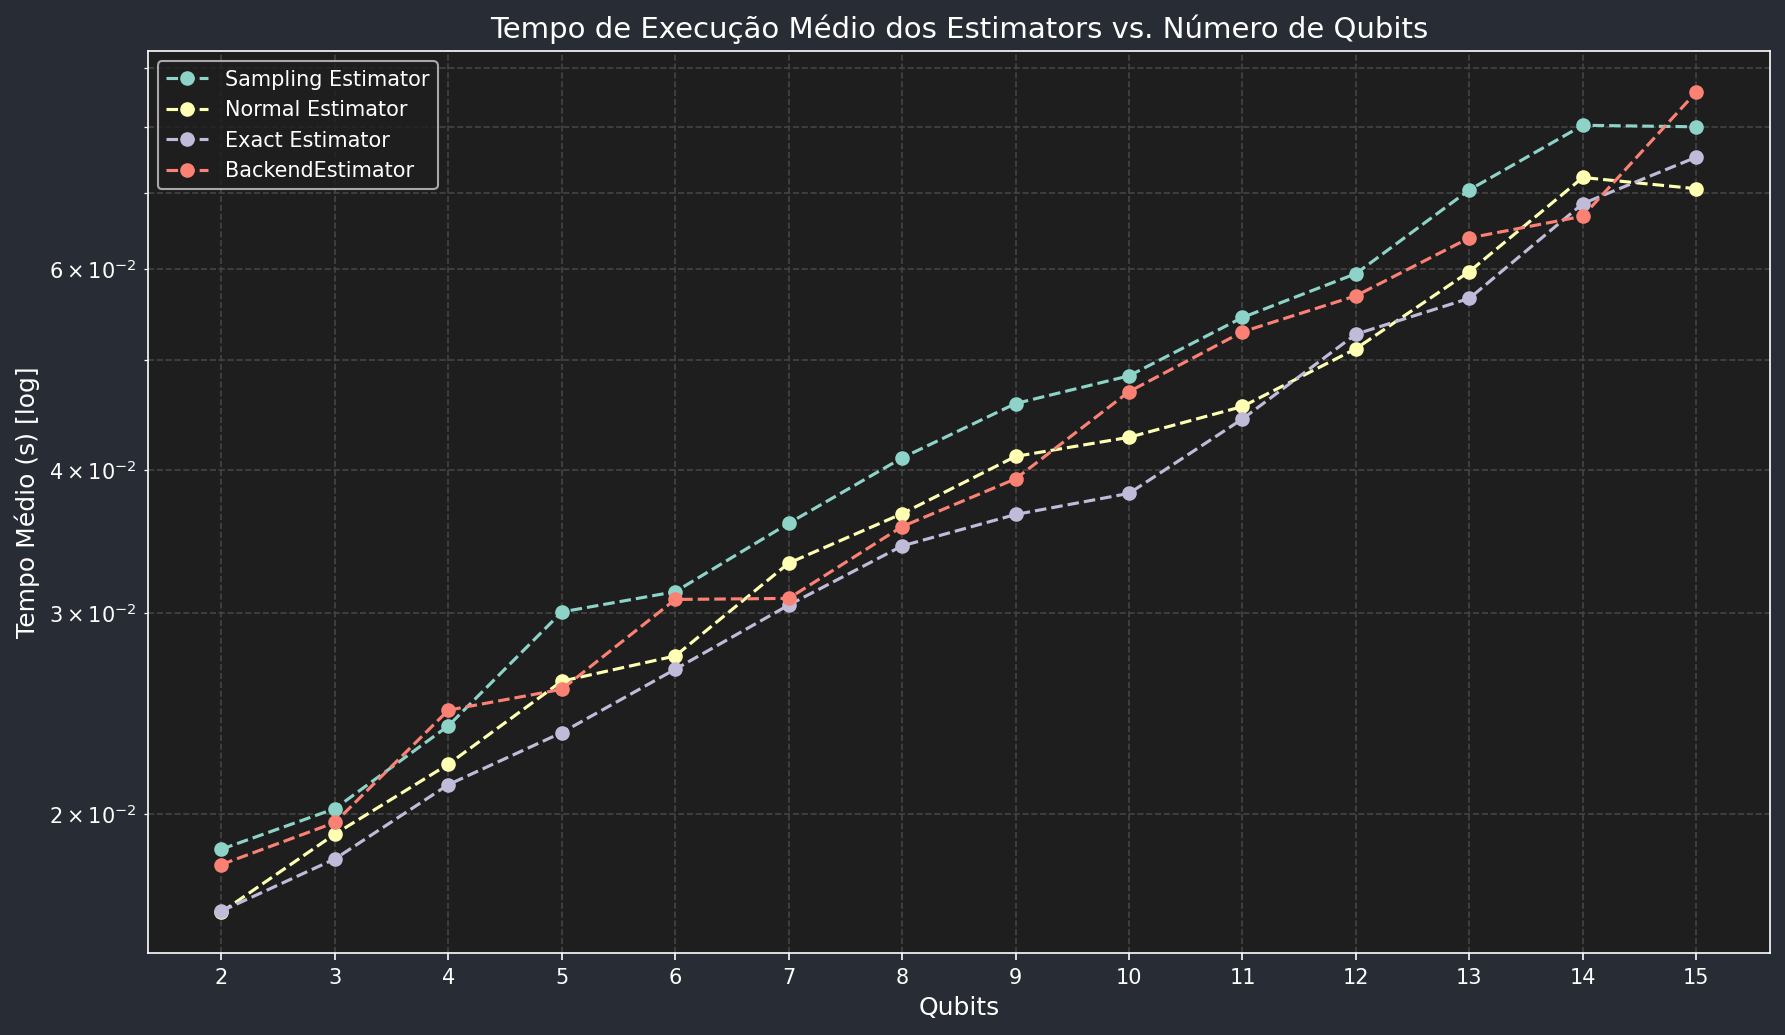

In [34]:
plt.figure(figsize=(12, 7))
for i, name in enumerate(method_names):
     plt.plot(qubit_range, times[name], "o--", label=name)

plt.xlabel("Qubits", fontsize=12)
plt.ylabel("Tempo Médio (s) [log]", fontsize=12)
plt.title("Tempo de Execução Médio dos Estimators vs. Número de Qubits", fontsize=14)
plt.yscale('log')
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

___

# [EstimatorV2](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.primitives.EstimatorV2.html) - Aer


`class EstimatorV2(*, options: dict | None = None)`

Esse estimator é mais recente e o padrão a ser utilizado oficialmente para o qiskit ver. >1.0. Apenas devemos nos preocupar com o options e 
___

## options: dict

Aqui temos a única configuração do EstimatorV2, onde podemos configurar as seguintes propriedades: 

1. default_precision
2. backend_options 
3. run_options

___

### default_precision

A default_precision é responsável por definir a precisão alvo padrão para o erro estatístico do valor esperado. Um valor menor pode levar o simulador a usar mais shots.

Por padrão, default_precision=0.0 o que siginifica que o estimator realizará um **cálculo exato**, assim como no Exact Estimator do EstimatorV1, que correspondia a alternativa de shots = None e approximation = True.

Quando temos uma default_precision > 0.0, o EstimatorV2 utilizará um **cálculo de amostragem com distribuição nomrmal**, equivalente ao Normal Estimator do EstimatorV1, que utilizava shots = int e approximation = True.

Basicamente esse simulador removeu completamente a possibilidade de utilizar o método de approximation = False que tinhamos no EstimatorV1.

___

### backend_options

Para as backend_options temos as mesmas opções que no EstimatorV1, que basicamente correspondem às opções de backend do AerSimulator (5. Misc/Qiskit Modules/3. AerSimulator.ipynb)

- method, device
- precision, zero_threshold, enable_truncation
- executor, max_parallel_threads, max_memory_mb, max_job_size, max_shot_size 
- noise_model, basis_gates 

___

### run_options

- shots (None or int) – The number of shots. 

- seed (int) – Set a fixed seed for the sampling.

___

## Run

`run(pubs: Iterable[EstimatorPubLike], *, precision: float | None = None) → PrimitiveJob[PrimitiveResult[PubResult]]`

Retorna um job com o resultado do valor esperado de cada PUB (Primitive Unified Bloc):

- pubs – An iterable of pub-like objects, such as tuples (circuit, observables) or (circuit, observables, parameter_values).

- precision – The target precision for expectation value estimates of each run Estimator Pub that does not specify its own precision. If None the estimator’s default precision value will be used.


In [4]:
estimator_v2 = EstimatorV2()
print(estimator_v2.options)

Options(default_precision=0.0, backend_options={}, run_options={})


In [5]:
num_qubits, depth = 10, 10

qc = clifford_qc(num_qubits, depth)

observable = SparsePauliOp.from_list([("".join(['I']*(num_qubits-1-i) + ['Z'] + ['I']*i), 1.0) for i in range(num_qubits)])

estimator_v2_sampling = EstimatorV2()

result = estimator_v2_sampling.run([(qc, observable)], precision=0.01).result()

print(f"job.results() : {result}\njob.results()[0] : {result[0]}\njob.results()[0].data : {result[0].data}\njob.results()[0].data.evs : {result[0].data.evs}")

job.results() : PrimitiveResult([PubResult(data=DataBin(evs=0.0016127611860390324, stds=np.ndarray(<shape=(), dtype=float64>)), metadata={'target_precision': 0.01, 'simulator_metadata': {'time_taken_parameter_binding': 9.95e-05, 'time_taken_execute': 0.005804, 'omp_enabled': True, 'max_gpu_memory_mb': 0, 'max_memory_mb': 15882, 'parallel_experiments': 1}})], metadata={})
job.results()[0] : PubResult(data=DataBin(evs=0.0016127611860390324, stds=np.ndarray(<shape=(), dtype=float64>)), metadata={'target_precision': 0.01, 'simulator_metadata': {'time_taken_parameter_binding': 9.95e-05, 'time_taken_execute': 0.005804, 'omp_enabled': True, 'max_gpu_memory_mb': 0, 'max_memory_mb': 15882, 'parallel_experiments': 1}})
job.results()[0].data : DataBin(evs=0.0016127611860390324, stds=np.ndarray(<shape=(), dtype=float64>))
job.results()[0].data.evs : 0.0016127611860390324


___

## Testando interação entre Precision e Shots

Assim como acabamos de ver na introdução do EstimatorV2, quando utilizamos o default_precision = 0 na declaração do Estimator, ou o precision = 0 no .run (métodos equivalentes) devemos ter um resultado exato, sem sampling. Porém, o que acontece se além de colocar o precision como nulo, adicionarmos um valor para o Shots? E se o contrário ocorrer, colocando o Shots = None, porém uma precisão maior que zero? 

1. Sampling EstimatorV2 : `Type(shots) = int` e `precision > 0`
2. Exact EstimatorV2 : `shots = None` e `precision = 0`
3. Caso 1 : `Type(shots) = int` e `precision = 0`
4. Caso 2 : `shots = None` e `precision > 0`


Para fazer esse teste utilizaremos outro gerador de circuitos em conjunto com um operador distinto. Para o circuito e observável utilizaremos um par com valor esperado conhecido, para poder testar os resultado. O valor esperado que esperamos é de 0.5

In [6]:
num_qubits = 4
shots = 2048
num_runs = 100
teorico_exato = 0.5

resultados = {
    "Normal Estimator (V1)": [],
    "Exact Estimator (V1)": [],
    "Sampling EstimatorV2 (V2)": [],
    "Exact EstimatorV2 (V2)": [],
    "Cenário 1 (V2)": [],
    "Cenário 2 (V2)": []
}

for _ in range(num_runs):
    
    qc = QuantumCircuit(num_qubits)
    qc.rx(np.pi / 3, 0)
    observable = SparsePauliOp("I" * (num_qubits - 1) + "Z")

    estimator_v1_normal = Estimator(approximation=True)
    result = estimator_v1_normal.run(qc, observable, shots=shots).result()
    resultados["Normal Estimator (V1)"].append(result.values[0])
    
    estimator_v1_exact = Estimator(approximation=True)
    result = estimator_v1_exact.run(qc, observable, shots=None).result()
    resultados["Exact Estimator (V1)"].append(result.values[0])

    options_sampling_v2 = {"run_options": {"shots": shots}}
    estimator_v2_sampling = EstimatorV2(options=options_sampling_v2)
    result = estimator_v2_sampling.run([(qc, observable)], precision=0.01).result()
    resultados["Sampling EstimatorV2 (V2)"].append(result[0].data.evs)

    estimator_v2_exact = EstimatorV2()
    result = estimator_v2_exact.run([(qc, observable)], precision=0.0).result()
    resultados["Exact EstimatorV2 (V2)"].append(result[0].data.evs)

    options_scenario_1 = {"run_options": {"shots": shots}}
    estimator_v2_scenario_1 = EstimatorV2(options=options_scenario_1)
    result = estimator_v2_scenario_1.run([(qc, observable)], precision=0.0).result()
    resultados["Cenário 1 (V2)"].append(result[0].data.evs)
    
    options_scenario_2 = {"run_options": {"shots": 0}}
    estimator_v2_scenario_2 = EstimatorV2(options=options_scenario_2)
    result = estimator_v2_scenario_2.run([(qc, observable)], precision=0.01).result()
    resultados["Cenário 2 (V2)"].append(result[0].data.evs)

In [10]:
print("\n--- Análise Final dos Resultados ---")
print(f"Valor Teórico Exato Esperado: {teorico_exato}")
print("-" * 70)
print(f"{'Cenário de Teste':<35} | {'Valor Médio (100 execs)':<25}")
print("-" * 70)

for name, data_list in resultados.items():
    media = np.mean(data_list)
    
    print(f"{name:<35} | {(media):<25.8f}")
print("-" * 70)


--- Análise Final dos Resultados ---
Valor Teórico Exato Esperado: 0.5
----------------------------------------------------------------------
Cenário de Teste                    | Valor Médio (100 execs)  
----------------------------------------------------------------------
Normal Estimator (V1)               | 0.50120696               
Exact Estimator (V1)                | 0.50000000               
Sampling EstimatorV2 (V2)           | 0.49945461               
Exact EstimatorV2 (V2)              | 0.50000000               
Cenário 1 (V2)                      | 0.50000000               
Cenário 2 (V2)                      | 0.49879540               
----------------------------------------------------------------------


Com esse resultado podemos tirar algumas conclusões:

1. O Exact Estimator (V1) e o Exact EstimatorV2 (V2) de fato estimaram de maneira correta o valor esperado do circuito e observável

2. Normal Estimator (V1) e Sampling EstimatorV2 (V2) correspondem a estimators com sampling, dado a inacurácia com relação ao valor teórico

- Cenário 1 : `shots = int` e `precision = 0`
- Cenário 2 : `shots = None` e `precision > 0`

3. O Cenário 1 resultou em um Exact EstimatorV2, portanto, o `precision` tem **precedência** sobre o `shots`. 

4. O Cenário 2 resultou em um Sampling EstimatorV2 (V2), novamente ressaltando a **precedência** do `precision` sobre o `shots`. O problema é que não sabemos a quantidade de shots que foi utilizada para essa simulação, dado que foi estipulado um valor de `shots = None`. 

*Recomendação : Não utilizar  Cenário 2*

___ 

# Comparação de Resultados e Performance 

Vamos realizar o mesmo teste feito anteriormente, porem comparando os equivalentes para o estimator V1 e V2 : 

1. Normal Estimator (V1) 
2. Sampling Estimator (V1)
3. BackendEstimator (V1)
4. Exact Estimator (V1)
5. Sampling EstimatorV2 (V2)
6. Exact EstimatorV2 (V2)

In [13]:
def expectation_value_total(num_qubits, depth, shots):
    
    results = {}
    
    qc = clifford_qc(num_qubits, depth)
    
    observable = SparsePauliOp.from_list([("".join(['I']*(n_qubits-1-i) + ['Z'] + ['I']*i), 1.0) for i in range(n_qubits)])
    
    start_time = time.time()
    estimator_sampling = Estimator(approximation = False)
    result = estimator_sampling.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Sampling Estimator"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_normal = Estimator(approximation = True)
    result = estimator_normal.run(qc, observable, shots = shots).result()
    end_time = time.time()
    results["Normal Estimator"] = [result.values[0], end_time - start_time]

    start_time = time.time()
    estimator_exact = Estimator(approximation = True)
    result = estimator_exact.run(qc, observable, shots = None).result()
    end_time = time.time()
    results["Exact Estimator"] = [result.values[0], end_time - start_time] 

    start_time = time.time()
    estimator_backendestimator = BackendEstimator(backend = AerSimulator())
    result = estimator_backendestimator.run(qc, observable, shots=shots).result()
    end_time = time.time()
    results["BackendEstimator"] = [result.values[0], end_time - start_time]
    
    start_time = time.time()
    options_sampling_v2 = {"run_options": {"shots": shots}}
    estimator_v2_sampling = EstimatorV2(options=options_sampling_v2)
    result = estimator_v2_sampling.run([(qc, observable)], precision=0.01).result()
    end_time = time.time()
    results["Sampling EstimatorV2"] = [result[0].data.evs, end_time - start_time]

    start_time = time.time()
    estimator_v2_exact = EstimatorV2()
    result = estimator_v2_exact.run([(qc, observable)], precision=0.0).result()
    end_time = time.time()
    results["Exact EstimatorV2"] = [result[0].data.evs, end_time - start_time]
    
    
    return results

qubit_range, depth = range(2, 16), 15
shots = 1024
iterations = 100

method_names = [
    "Sampling Estimator",
    "Normal Estimator",
    "Exact Estimator",
    "BackendEstimator",
    "Sampling EstimatorV2",
    "Exact EstimatorV2"
]

times = {name: [] for name in method_names}
values = {name: [] for name in method_names}

warnings.filterwarnings('ignore', category=DeprecationWarning)

for n_qubits in qubit_range:

    temp_times = {name: [] for name in method_names}
    temp_values = {name: [] for name in method_names}

    for a in range(iterations):
        
        result = expectation_value_total(num_qubits=n_qubits, depth=depth, shots=shots)
        
        temp_times["Sampling Estimator"].append(result["Sampling Estimator"][1])
        temp_values["Sampling Estimator"].append(result["Sampling Estimator"][0])
    
        temp_times["Normal Estimator"].append(result["Normal Estimator"][1])
        temp_values["Normal Estimator"].append(result["Normal Estimator"][0])

        temp_times["Exact Estimator"].append(result["Exact Estimator"][1])
        temp_values["Exact Estimator"].append(result["Exact Estimator"][0])

        temp_times["BackendEstimator"].append(result["BackendEstimator"][1])
        temp_values["BackendEstimator"].append(result["BackendEstimator"][0])

        temp_times["Sampling EstimatorV2"].append(result["Sampling EstimatorV2"][1])
        temp_values["Sampling EstimatorV2"].append(result["Sampling EstimatorV2"][0])

        temp_times["Exact EstimatorV2"].append(result["Exact EstimatorV2"][1])
        temp_values["Exact EstimatorV2"].append(result["Exact EstimatorV2"][0])

    for name in method_names:
        times[name].append(np.mean(temp_times[name]))
        values[name].append(np.mean(temp_values[name]))

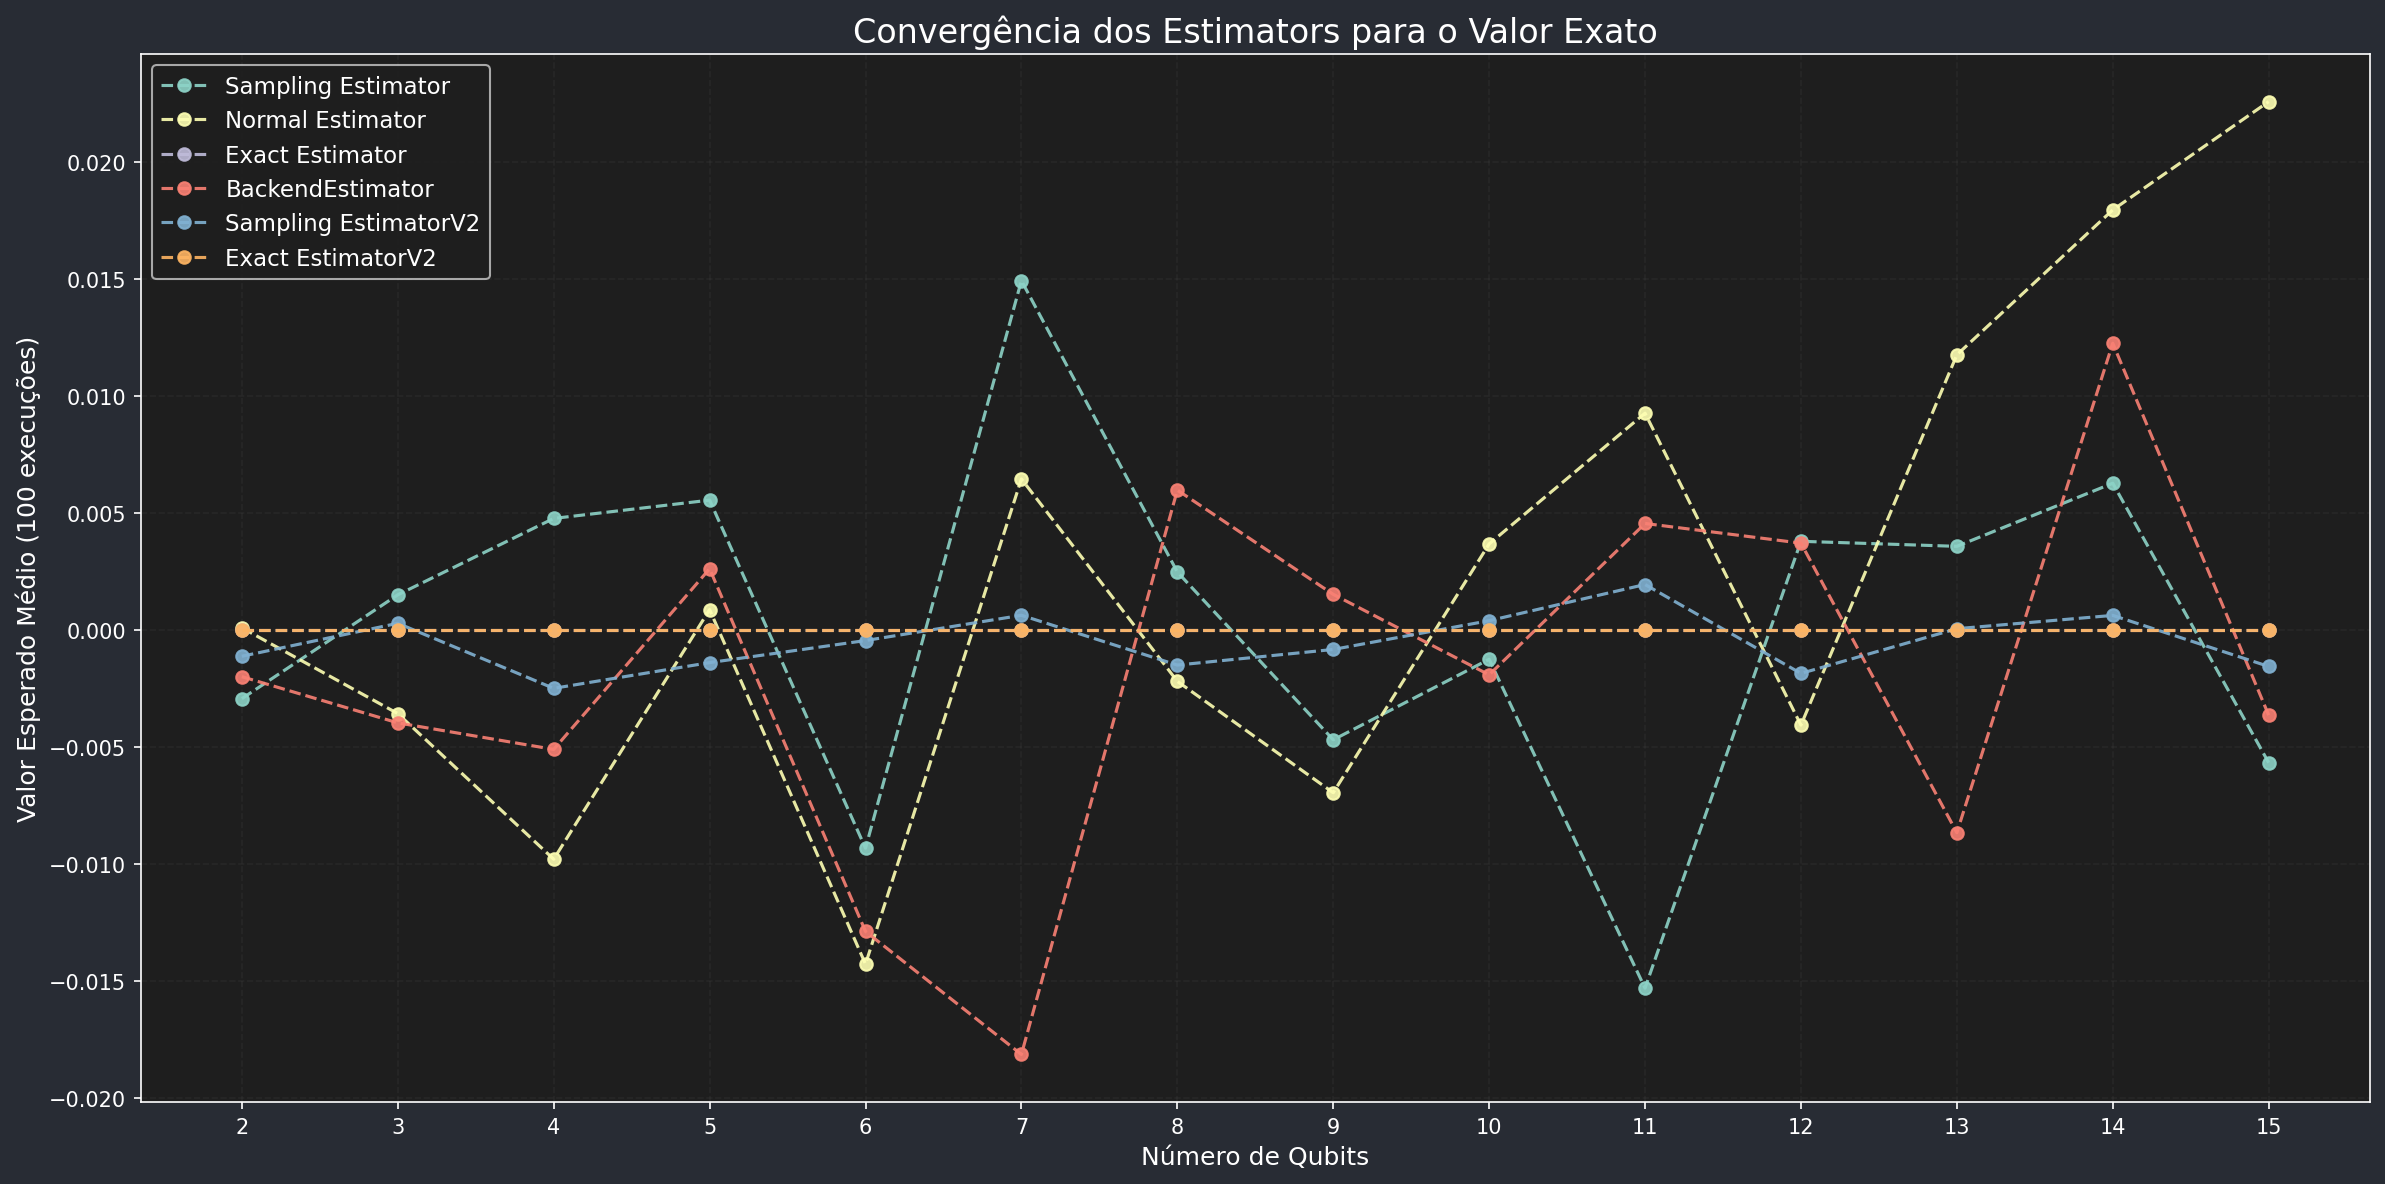

In [25]:
plt.figure(figsize=(16, 8))
for i, name in enumerate(method_names):
    plt.plot(qubit_range, values[name], "o--", label=name, alpha=0.9)

plt.xlabel("Número de Qubits", fontsize=12)
plt.ylabel("Valor Esperado Médio (100 execuções)", fontsize=12)
plt.title("Convergência dos Estimators para o Valor Exato", fontsize=16)
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--", alpha=0.25)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

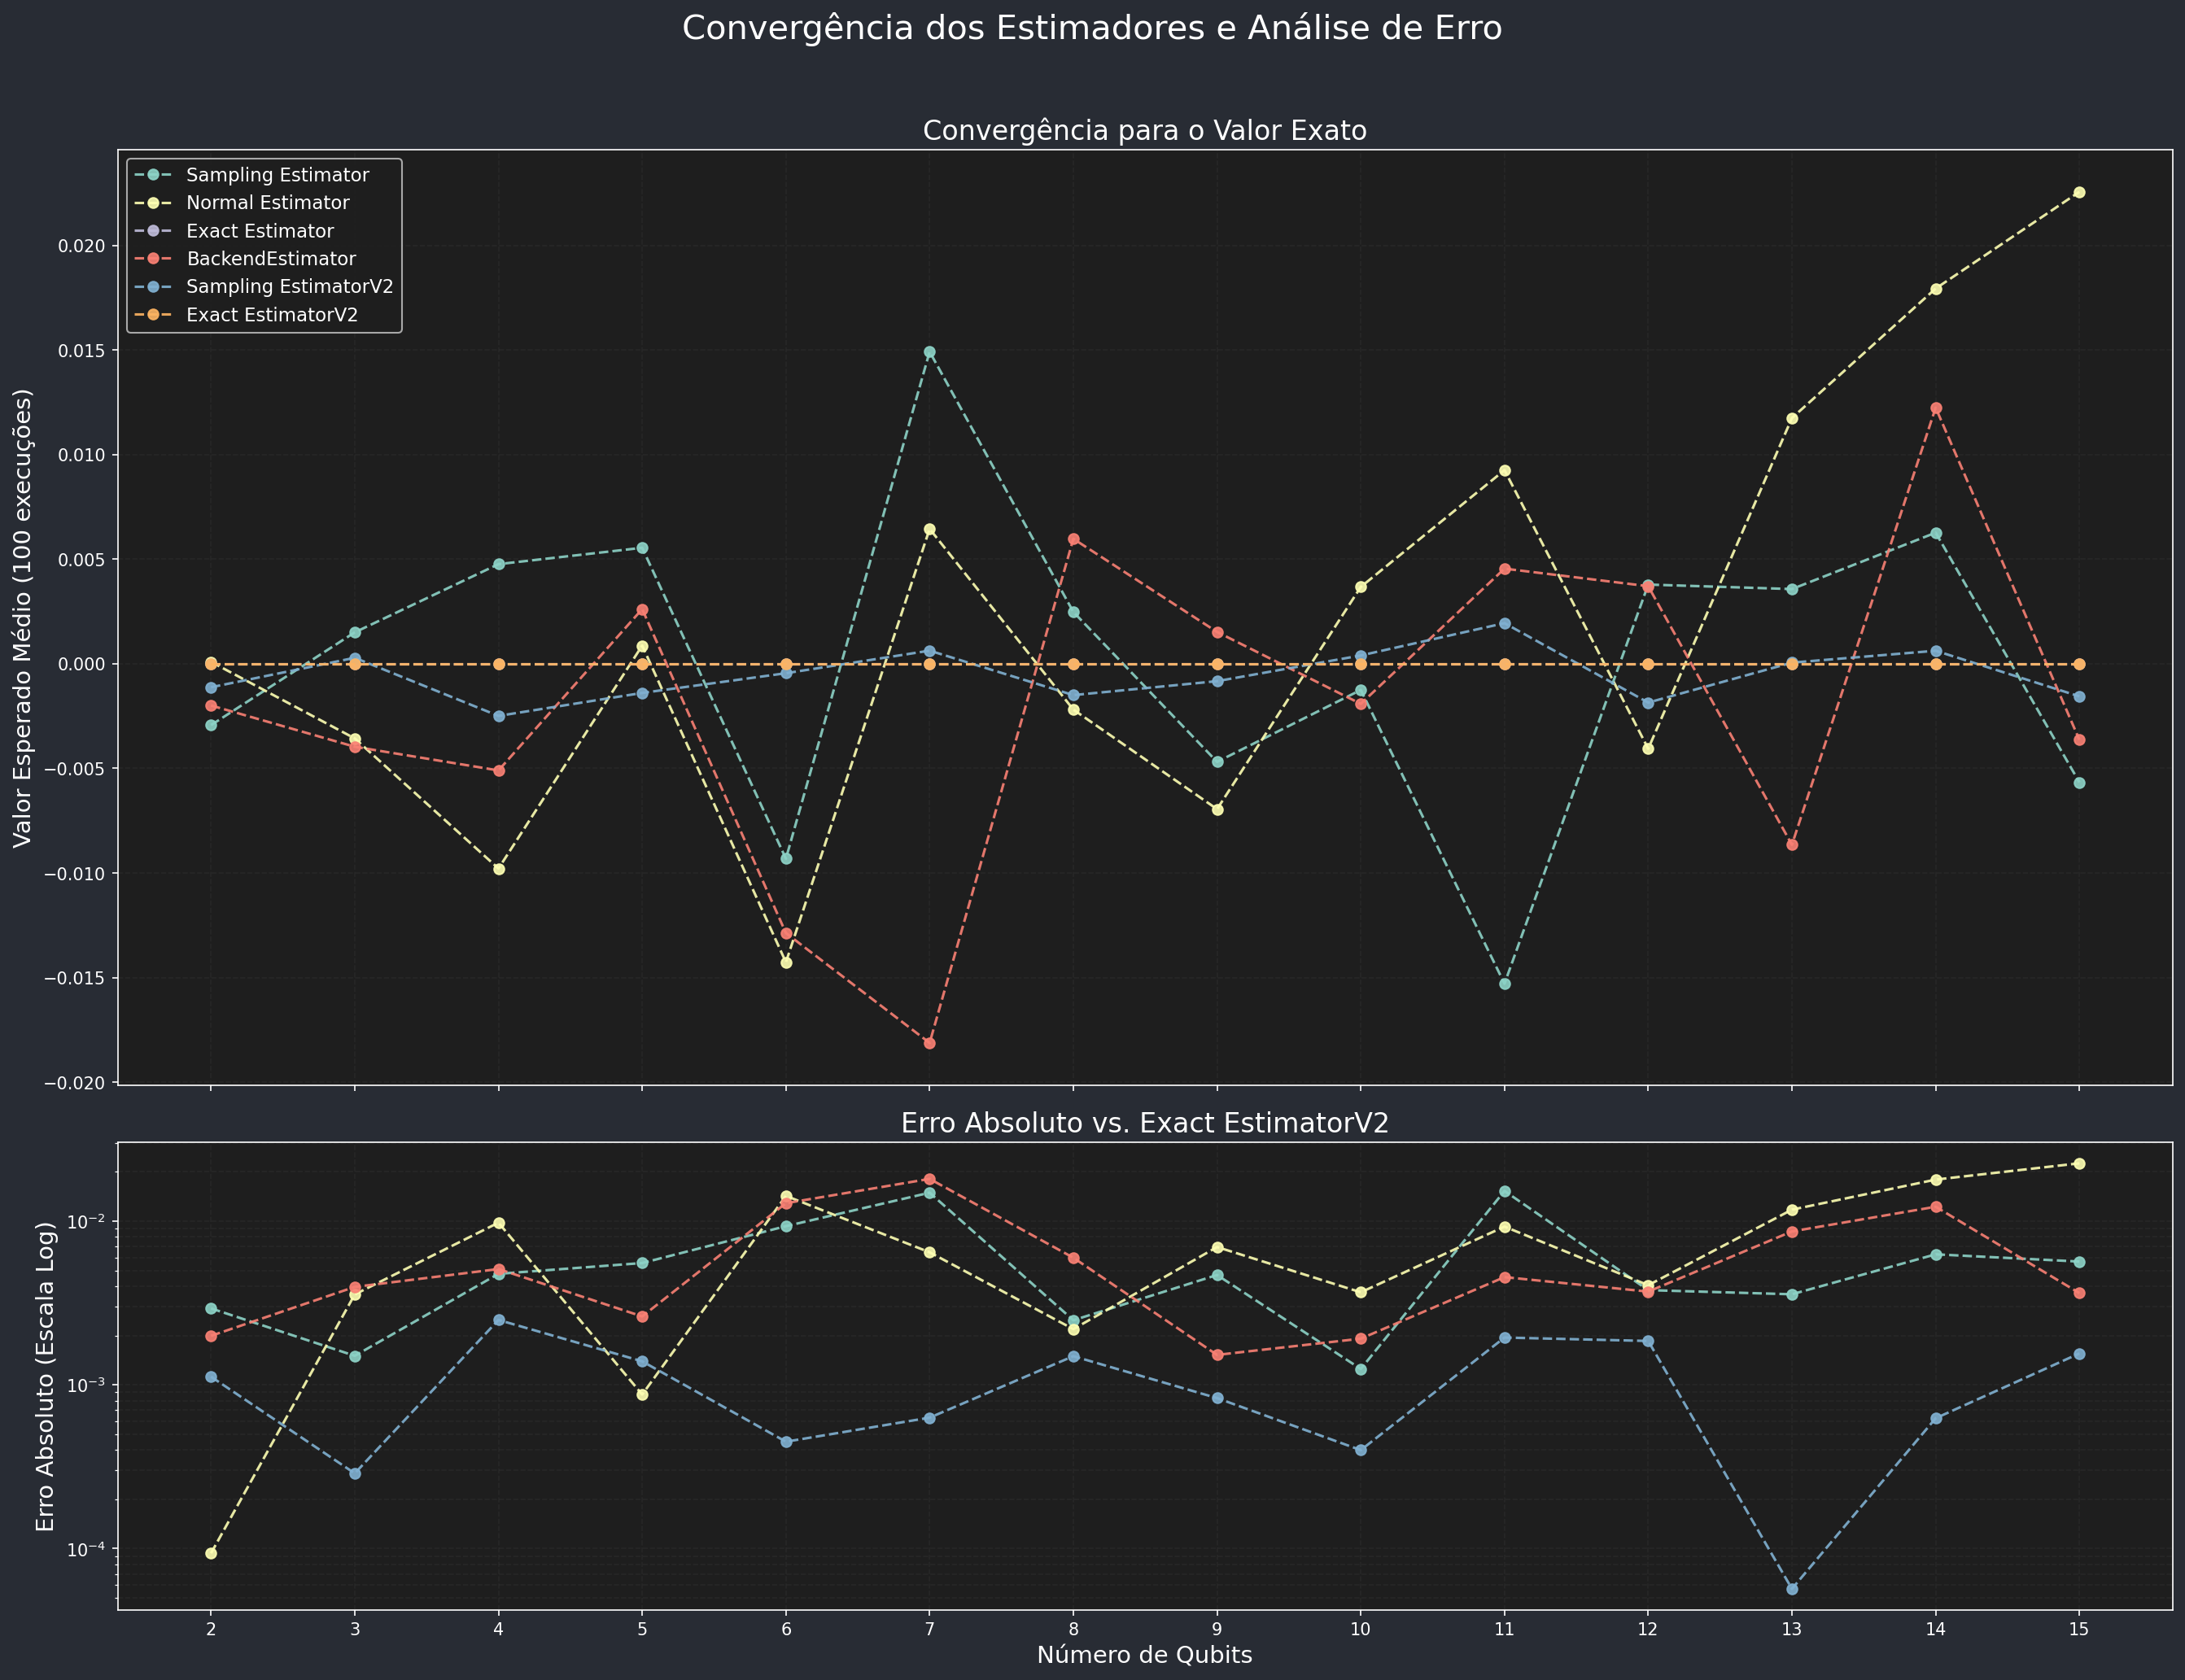

In [24]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

color_map = {name: color for name, color in zip(method_names, colors)}

exact_values_baseline = values["Exact EstimatorV2"]

errors = {}
error_method_names = [name for name in method_names if "Exact" not in name]
for name in error_method_names:
    errors[name] = np.abs(np.array(values[name]) - np.array(exact_values_baseline))

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(18, 14), 
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)
fig.suptitle("Convergência dos Estimadores e Análise de Erro", fontsize=20)

ax1.set_title("Convergência para o Valor Exato", fontsize=16)
for name in method_names:
    ax1.plot(qubit_range, values[name], 
             "o--",
             label=name, 
             alpha=0.9,
             color=color_map[name])

ax1.set_ylabel(f"Valor Esperado Médio ({iterations} execuções)", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.25)

ax2.set_title("Erro Absoluto vs. Exact EstimatorV2", fontsize=16)
for name in error_method_names:
    ax2.plot(qubit_range, errors[name], 
             "o--",
             color=color_map[name],
             alpha=0.9)

ax2.set_xlabel("Número de Qubits", fontsize=14)
ax2.set_ylabel("Erro Absoluto (Escala Log)", fontsize=14)
ax2.set_xticks(qubit_range)
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--", alpha=0.25)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

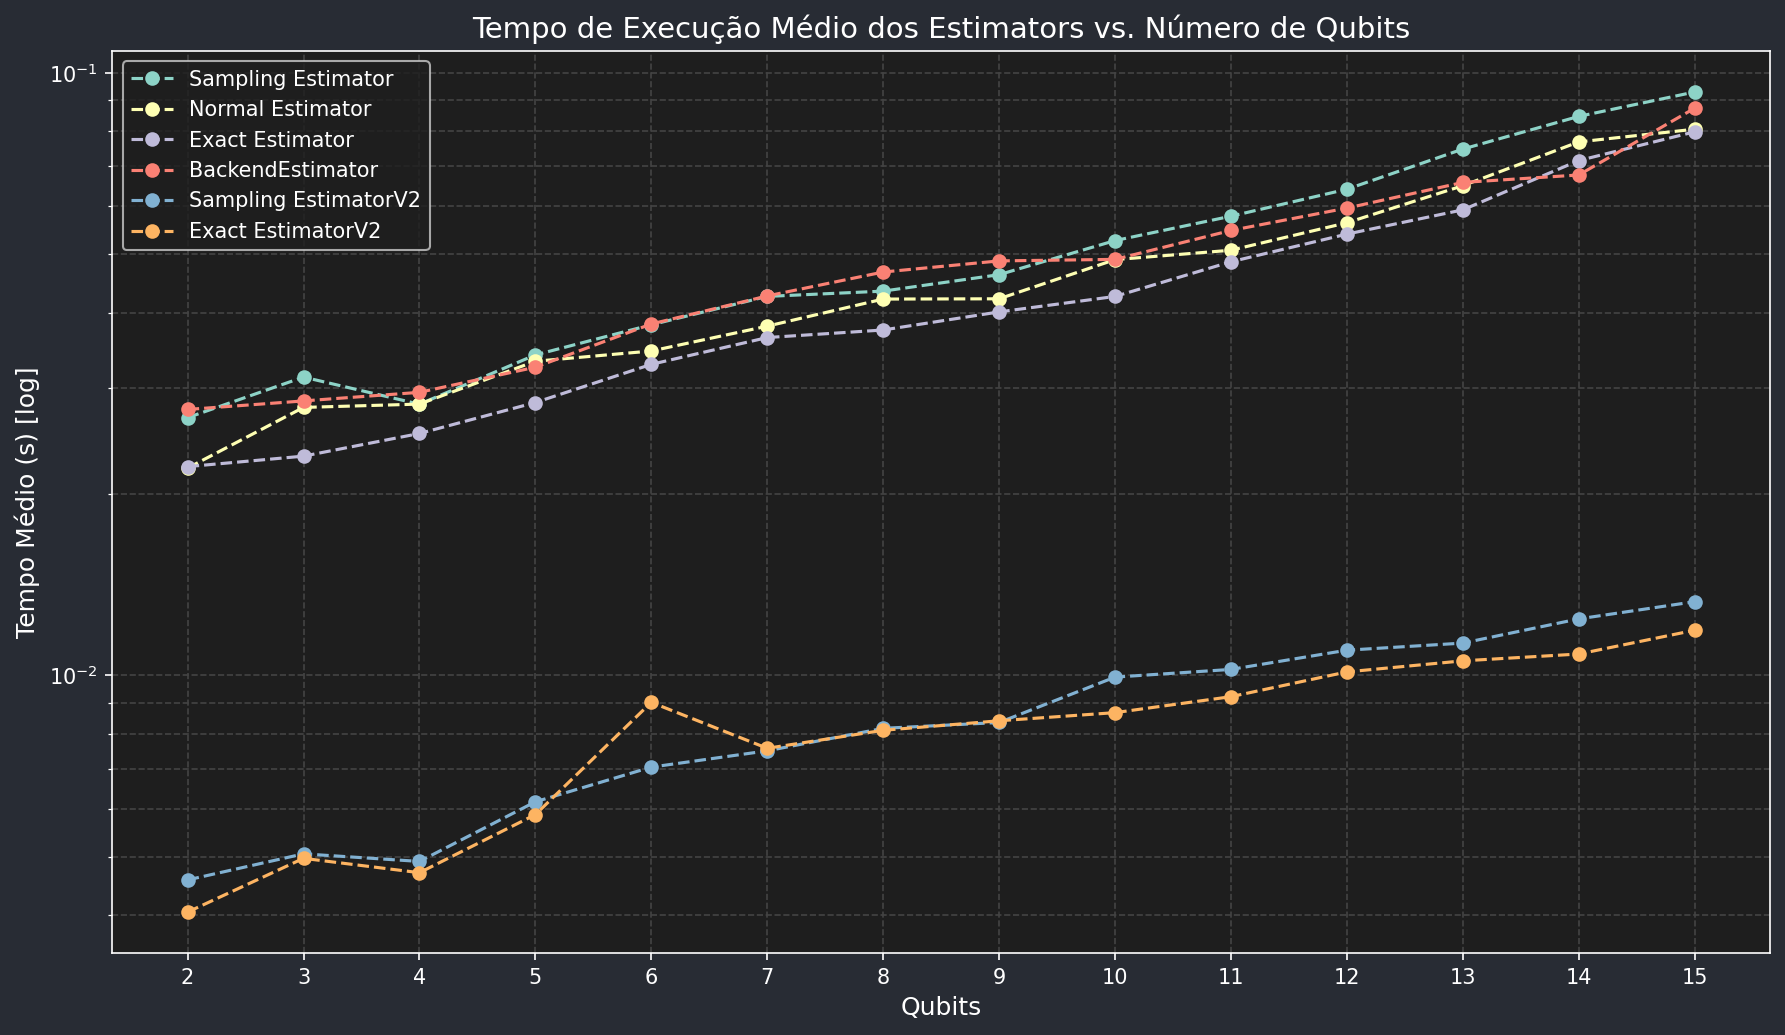

In [26]:
plt.figure(figsize=(12, 7))
for i, name in enumerate(method_names):
     plt.plot(qubit_range, times[name], "o--", label=name)

plt.xlabel("Qubits", fontsize=12)
plt.ylabel("Tempo Médio (s) [log]", fontsize=12)
plt.title("Tempo de Execução Médio dos Estimators vs. Número de Qubits", fontsize=14)
plt.yscale('log')
plt.xticks(qubit_range)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Com essa sequencia de gráficos podemos concluir de maneira contundente que **o EstimatorV2 é melhor que a versão V1 em precisão e eficiência**, dado que o Sampling EstimatorV2 foi aquele que apresentou menor erro médio entre todos os outros métodos, além de demorar muito menos para rodar o mesmo código